# Notebook 01 — Baseline: per-attack AUC and training loss curves

**Dissertation:** Detecting Forged Identity Documents Using Deep Learning
**Author:** Iko-Ojo Benjamin Ochai (202527287)

This notebook establishes the central baseline result: three off-the-shelf,
whole-image, ImageNet-pretrained classifiers (ResNet50, DenseNet121, ViT-B/16)
evaluated on the FantasyID test partition, reported as per-attack-type ROC-AUC.
It also plots the training and validation loss curves for all three models.

**Provenance.** This notebook is self-contained: the compute functions are inlined
here so the notebook runs standalone, but they are the same functions used in the
project source tree (`src/evaluate.py`, `src/plot_loss_curves.py`). It reads only
frozen artefacts produced by earlier runs:

- `checkpoints/scores_test_resnet50.csv`, `..._densenet121.csv`, `..._vit.csv`
  — per-sample predictions, columns `idx, y_true, p_forged, attack_type`.
- `results/<run>/metrics.csv` for the three canonical training runs,
  columns `step, train_loss, train_acc, val_loss, val_acc`.

No model is re-run here. AUCs are recomputed live from the frozen score files, so
the values below are reproduced from the same data that produced the report.

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# Frozen per-sample score files (one per model).
SCORE_FILES = {
    "ResNet50":    "checkpoints/scores_test_resnet50.csv",
    "DenseNet121": "checkpoints/scores_test_densenet121.csv",
    "ViT-B/16":    "checkpoints/scores_test_vit.csv",
}

# Canonical training-run folders (NOT the discarded duplicate runs).
RUN_DIRS = {
    "ResNet50":    "results/resnet50_baseline_20260609_205558",
    "DenseNet121": "results/densenet121_baseline_20260611_105734",
    "ViT-B/16":    "results/vit_baseline_20260617_112152",
}

## 1. Per-attack ROC-AUC

Each attack type is scored against the bonafide pool. The face AUC ranks the 150
face-swap forgeries against the 300 bonafide documents; the text AUC ranks the 935
text-edit forgeries against the same bonafide pool. This mirrors the evaluation
protocol used to generate the reported figures (`attack_type` rows versus the
`none` pool), so the AUCs here reproduce the baseline table in the report.

An AUC below 0.5 is an **inverted ranking**, not merely weak discrimination: the
model systematically scores that forgery class as *more genuine* than genuine
documents.

In [2]:
def per_attack_auc(df, attack):
    """ROC-AUC for one attack type versus the bonafide pool.

    Positives are rows of the given attack type; negatives are bonafide rows
    (attack_type == 'none'). p_forged is the model's forged-class score.
    """
    mask = df["attack_type"].isin([attack, "none"])
    sub = df[mask]
    y_true = (sub["attack_type"] == attack).astype(int)   # 1 = forgery, 0 = bonafide
    return roc_auc_score(y_true, sub["p_forged"])

rows = []
for model, path in SCORE_FILES.items():
    df = pd.read_csv(path)
    rows.append({
        "Architecture": model,
        "Face-swap AUC": per_attack_auc(df, "face"),
        "Text-edit AUC": per_attack_auc(df, "text"),
    })

auc_table = pd.DataFrame(rows).set_index("Architecture")

# Display all AUCs at uniform 4 dp. The frozen scores CSV stores p_forged to 6 dp,
# so these values are the canonical, reproducible figures and match the report table
# exactly (the report adopts these CSV-computed values as its source of truth).
display(auc_table.style.format({"Face-swap AUC": "{:.4f}", "Text-edit AUC": "{:.4f}"}))

,Face-swap AUC,Text-edit AUC
Architecture,,
ResNet50,0.9145,0.1365
DenseNet121,0.8872,0.1566
ViT-B/16,0.7740,0.1950


The face AUCs sit well above 0.5 and rank the architectures ResNet50 >
DenseNet121 > ViT-B/16. The text AUCs form a narrow band well below 0.5. The
inversion holds across two convolutional backbones and one vision transformer, so
it is not a single-architecture artefact. The shared property is that all three are
off-the-shelf, whole-image, ImageNet-pretrained classifiers. This is the central
empirical finding the dissertation develops.

All six values are computed here from the frozen per-sample score files and are the
canonical figures reported in the dissertation. They are shown to four decimal
places so the notebook output matches the report table exactly.

## 2. Test-partition composition

For provenance, the class balance of the test partition is recomputed from the
score files. The three files share the same 1385-document partition.

In [3]:
df_ref = pd.read_csv(SCORE_FILES["ResNet50"])
comp = df_ref["attack_type"].value_counts().rename({"none": "bonafide"})
comp = comp.rename("count").to_frame()
comp.index.name = "class"
print("Total documents:", len(df_ref))
display(comp)

Total documents: 1385


,count
class,
text,935
bonafide,300
face,150


This is the deliberately imbalanced FantasyID test partition: 300 bonafide,
150 face-swap, 935 text-edit, with no combined face-and-text attacks. The heavy
text share is a property of the benchmark, not a sampling choice made here.

## 3. Training and validation loss curves

Loss curves for the three canonical runs on shared axes. Each `metrics.csv` logs
one row per epoch (`step`), with training and validation loss. These plots
visualise convergence speed and the train/validation gap across architectures.

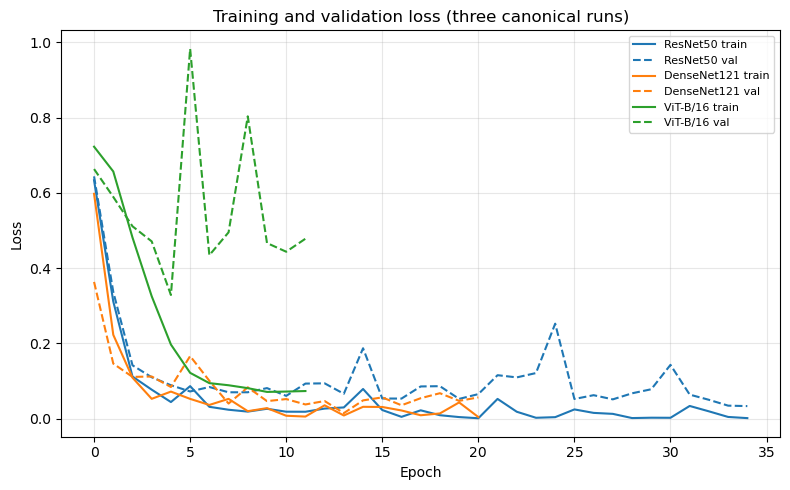

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {"ResNet50": "tab:blue", "DenseNet121": "tab:orange", "ViT-B/16": "tab:green"}

for model, run_dir in RUN_DIRS.items():
    m = pd.read_csv(f"{run_dir}/metrics.csv")
    c = colors[model]
    ax.plot(m["step"], m["train_loss"], color=c, linestyle="-",  label=f"{model} train")
    ax.plot(m["step"], m["val_loss"],   color=c, linestyle="--", label=f"{model} val")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training and validation loss (three canonical runs)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Solid lines are training loss, dashed lines validation loss. The
convergence-speed differences and train/validation gaps are discussed in the
report. The runs plotted are the canonical baselines whose checkpoints produced the
AUCs in Section 1, not the discarded duplicate runs.